In [35]:
#importing libraries
import pandas as pd
import matplotlib.pyplot as plt
from datasets import load_dataset
import seaborn as sns

#loading data
dataset=load_dataset('lukebarousse/data_jobs')

#converting the loaded dataset into a pandas dataframe
df=dataset['train'].to_pandas()

#formatting datetime
df['job_posted_date']=pd.to_datetime(df['job_posted_date'])

#cleaning the job_skills column by converting them from strings into lists
import ast
df['job_skills']=df['job_skills'].apply(lambda skills: ast.literal_eval(skills) if pd.notna(skills) else skills )

In [36]:
#Filtering out Business analyst jobs in the US
df_us=df[(df['job_title_short']=='Business Analyst') & (df['job_country']=='United States')]

In [37]:
# creating a month no. column in the dataframe
df_us['month_no']=df_us['job_posted_date'].dt.month

C:\Users\Varsha\AppData\Local\Temp\ipykernel_21288\3220388846.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_us['month_no']=df_us['job_posted_date'].dt.month


In [38]:
#exploding the skills column
df_exploded= df_us.explode('job_skills')

In [39]:
#creating a pivot table that groups the month no and exploded skills, filling the NA values with 0
df_pivot=df_exploded.pivot_table(index='month_no', columns='job_skills', aggfunc='size', fill_value=0)

In [40]:
#calculating the sum of each of skill and sorting the pivot table based on the sum
df_pivot.loc['total']=df_pivot.sum()
df_pivot=df_pivot[df_pivot.loc['total'].sort_values(ascending=False).index]
df_pivot=df_pivot.drop('total')

In [41]:
#creating a new dataframe that provides the no.of jobs posted each month
df_jobs=df_us.groupby('month_no').size()


In [42]:
#calculating the skill percent using no.of posted each month
df_percent=df_pivot.div(df_jobs/100, axis=0)

In [43]:
#resetting the index of the dataframe
df_percent=df_percent.reset_index()

In [ ]:
#creating a month name column and dropping the month no column
df_percent['month_name']=pd.to_datetime(df_percent['month_no'], format='%m').dt.strftime('%b')
df_percent=df_percent.set_index('month_name')
df_percent=df_percent.drop(columns='month_no')

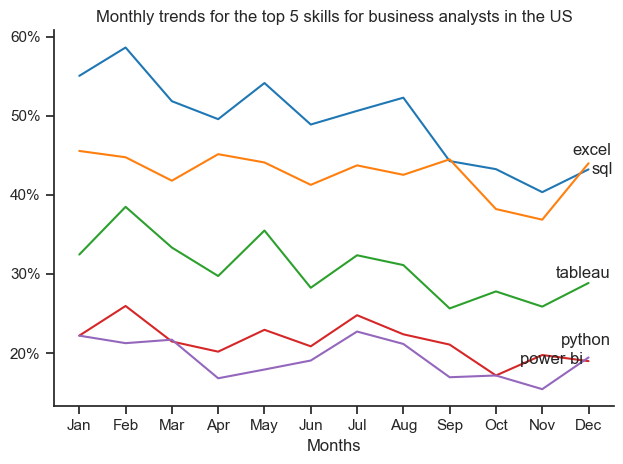

In [64]:
#plotting a line graph for the top 5 skills to show their monthly trends
from adjustText import adjust_text
df_plot=df_percent.iloc[0:12, 0:5]
sns.set_theme(style='ticks')
sns.lineplot(df_plot, dashes=False, legend=False, palette='tab10' )
plt.title('Monthly trends for the top 5 skills for business analysts in the US')
plt.xlabel('Months')
texts=[]
for skill in df_plot.columns:
    texts.append(plt.text(x=11, y=df_plot[skill].iloc[-1], s=skill))
adjust_text(texts)
from matplotlib.ticker import PercentFormatter
ax=plt.gca()
ax.yaxis.set_major_formatter(PercentFormatter(decimals=False))
sns.despine()
plt.tight_layout()